In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [21]:
import pandas as pd

df = pd.read_excel("../data/Kittchen PNL Data.xlsx")

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2100 entries, 0 to 2099
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   MONTH            2100 non-null   str    
 1   CITY             2100 non-null   str    
 2   STORE            2100 non-null   str    
 3   STATUS           2100 non-null   str    
 4   ZONE MAPPING     2100 non-null   str    
 5   ORDER COUNT      2100 non-null   int64  
 6   CART SALES       2100 non-null   float64
 7   DISCOUNT         2100 non-null   float64
 8   NET REVENUE      2100 non-null   float64
 9   IDEAL FOOD COST  2100 non-null   float64
 10  GROSS MARGIN     2100 non-null   float64
 11  KITCHEN EBITDA   2100 non-null   float64
 12  VARIANCE         2100 non-null   float64
 13  REVENUE COHORT   2100 non-null   str    
 14  CM COHORT        2100 non-null   str    
 15  EBITDA CATEGORY  2100 non-null   str    
 16  EBITDA COHORT    2100 non-null   str    
dtypes: float64(7), int64(1), 

In [7]:
df.describe()

,ORDER COUNT,CART SALES,DISCOUNT,NET REVENUE,IDEAL FOOD COST,GROSS MARGIN,KITCHEN EBITDA,VARIANCE
count,2100.000000,2.100000e+03,2.100000e+03,2.100000e+03,2.100000e+03,2.100000e+03,2.100000e+03,2100.000000
mean,11045.371905,4.400591e+06,9.839992e+05,3.505318e+06,1.362716e+06,2.043380e+06,6.847230e+05,20176.588981
std,2290.859134,1.119388e+06,3.136288e+05,8.948390e+05,4.151767e+05,5.724239e+05,5.810918e+05,5783.204330
min,7002.000000,2.177493e+06,3.521976e+05,1.726080e+06,5.567911e+05,8.628336e+05,-5.858504e+05,10018.480000
25%,9097.000000,3.520108e+06,7.442392e+05,2.817943e+06,1.059971e+06,1.612744e+06,2.520450e+05,15494.855000
50%,10987.000000,4.295395e+06,9.388061e+05,3.427512e+06,1.298579e+06,1.980660e+06,6.176177e+05,20195.190000
75%,12986.750000,5.184657e+06,1.176024e+06,4.127204e+06,1.618120e+06,2.423338e+06,1.076676e+06,25180.827500
max,14999.000000,7.471638e+06,2.147224e+06,6.167425e+06,2.797857e+06,4.172730e+06,2.834680e+06,29993.940000


In [8]:
df.duplicated().sum()

np.int64(0)

In [40]:
df.columns = (
    df.columns
    .str.strip()
    .str.upper()
    .str.replace(" ", "_")
    .str.replace("-", "_")
    .str.replace(r'[^A-Z0-9_]', '', regex=True)
)

In [46]:
df.columns

Index(['MONTH', 'CITY', 'STORE', 'STATUS', 'ZONE_MAPPING', 'ORDER_COUNT',
       'CART_SALES', 'DISCOUNT', 'NET_REVENUE', 'IDEAL_FOOD_COST',
       'GROSS_MARGIN', 'KITCHEN_EBITDA', 'VARIANCE', 'REVENUE_COHORT',
       'CM_COHORT', 'EBITDA_CATEGORY', 'EBITDA_COHORT', 'VARIANCE_CATEGORY',
       'REVENUE_BUCKET', 'GM_PERCENT'],
      dtype='str')

In [45]:
df['GM_PERCENT'] = (
    df['GROSS_MARGIN'] / df['NET_REVENUE']
) * 100

In [47]:
df[['GROSS_MARGIN', 'NET_REVENUE', 'GM_PERCENT']].head()

,GROSS_MARGIN,NET_REVENUE,GM_PERCENT
0,3614747.39,5434068.17,66.520096
1,1414249.00,2146679.55,65.880769
2,2036999.44,3188606.71,63.883684
3,1451140.55,2734306.33,53.071616
4,2394567.16,3602124.88,66.476517


In [10]:
df['MONTH'] = pd.to_datetime(df['MONTH'])

C:\Users\hites\AppData\Local\Temp\ipykernel_22276\827087573.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['MONTH'] = pd.to_datetime(df['MONTH'])


In [11]:
df['GM_PERCENT'] = (df['GROSS_MARGIN'] / df['NET_REVENUE']) * 100
df['EBITDA_PERCENT'] = (df['KITCHEN_EBITDA'] / df['NET_REVENUE']) * 100

In [30]:
def variance_bucket(x):
    if x < 2:
        return 'Var <2%'
    elif x < 3:
        return 'Var 2%-3%'
    elif x < 5:
        return 'Var 3%-5%'
    else:
        return 'Var >5%'

In [33]:
df['VARIANCE_CATEGORY'] = df['VARIANCE'].apply(variance_bucket)

In [35]:
df['VARIANCE_CATEGORY'].value_counts()

VARIANCE_CATEGORY
Var 2%-3%    1070
Var <2%      1030
Name: count, dtype: int64

In [38]:
def revenue_bucket(x):
    if x < 1500000:
        return 'Below 15L'
    elif x < 2500000:
        return '15L-25L'
    elif x < 3500000:
        return '25L-35L'
    elif x < 4500000:
        return '35L-45L'
    else:
        return 'Above 45L'

df['REVENUE_BUCKET'] = df['NET REVENUE'].apply(revenue_bucket)
df['REVENUE_BUCKET'].value_counts()

REVENUE_BUCKET
25L-35L      834
35L-45L      689
Above 45L    299
15L-25L      278
Name: count, dtype: int64

In [ ]:
df['VARIANCE_CATEGORY'].value_counts()

VARIANCE_CATEGORY
Var 2%-3%    1070
Var <2%      1030
Name: count, dtype: int64

In [48]:
df.to_csv('../outputs/cleaned_pnl_data.csv', index=False)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

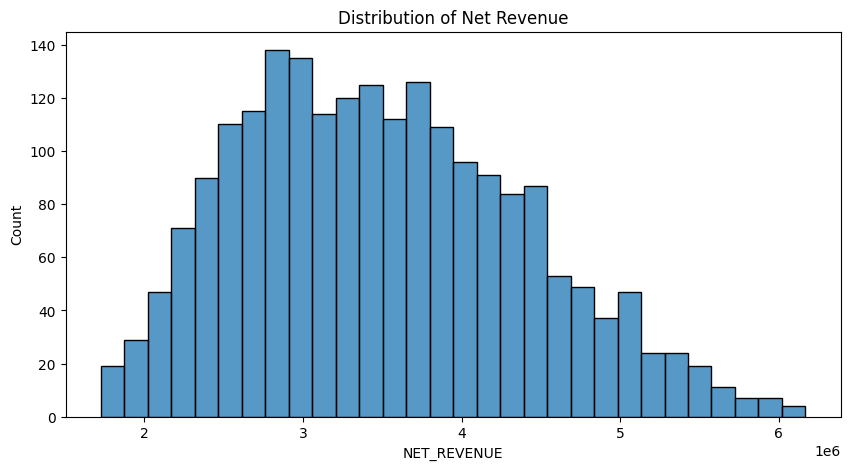

In [ ]:
plt.figure(figsize=(10,5))

sns.histplot(df['NET_REVENUE'], bins=30)

plt.title('Distribution of Net Revenue')

plt.show()

In [ ]:
city_revenue = df.groupby('CITY')['NET_REVENUE'].sum().sort_values(ascending=False)

city_revenue

CITY
Ahmedabad    1.848080e+09
Hyderabad    1.512076e+09
Bangalore    1.430733e+09
Mumbai       1.303669e+09
Pune         1.266610e+09
Name: NET_REVENUE, dtype: float64

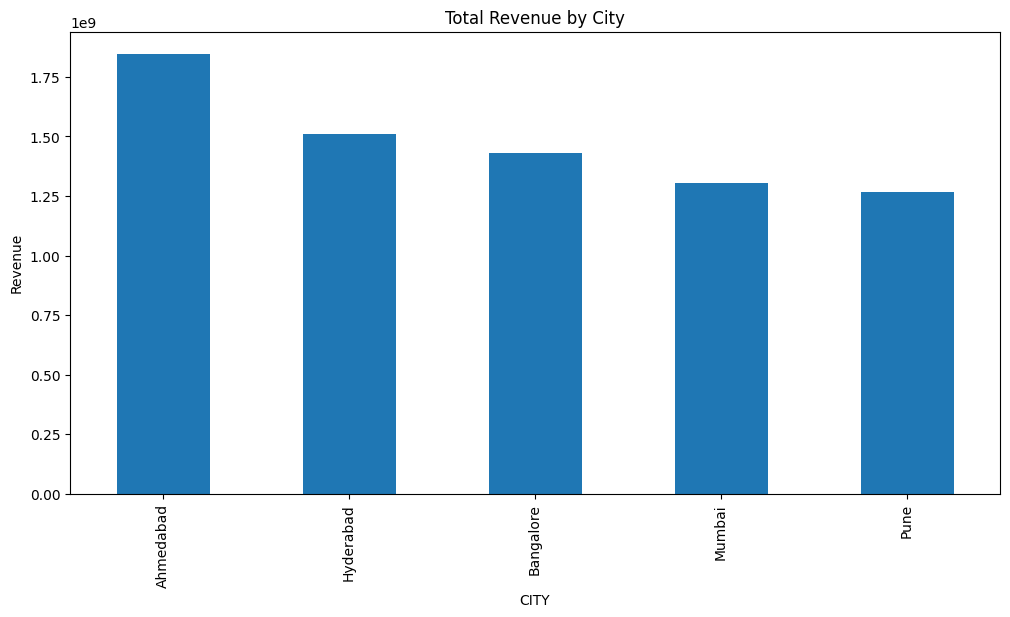

In [ ]:
plt.figure(figsize=(12,6))

city_revenue.plot(kind='bar')

plt.title('Total Revenue by City')

plt.ylabel('Revenue')

plt.show()

In [ ]:
plt.figure(figsize=(12,6))

top_stores.plot(kind='bar')

plt.title('Top 10 Revenue Generating Stores')

plt.ylabel('Revenue')

plt.show()


KeyboardInterrupt



<Figure size 1200x600 with 0 Axes>

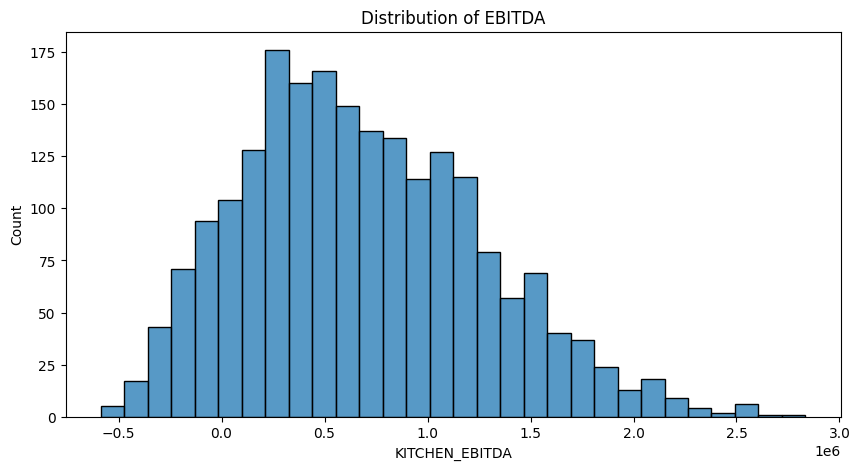

In [ ]:
plt.figure(figsize=(10,5))

sns.histplot(df['KITCHEN_EBITDA'], bins=30)

plt.title('Distribution of EBITDA')

plt.show()

In [ ]:
df['PROFIT_STATUS'] = df['KITCHEN_EBITDA'].apply(lambda x: 'Profitable' if x > 0 else 'Loss')
df['PROFIT_STATUS'].value_counts()

PROFIT_STATUS
Profitable    1859
Loss           241
Name: count, dtype: int64

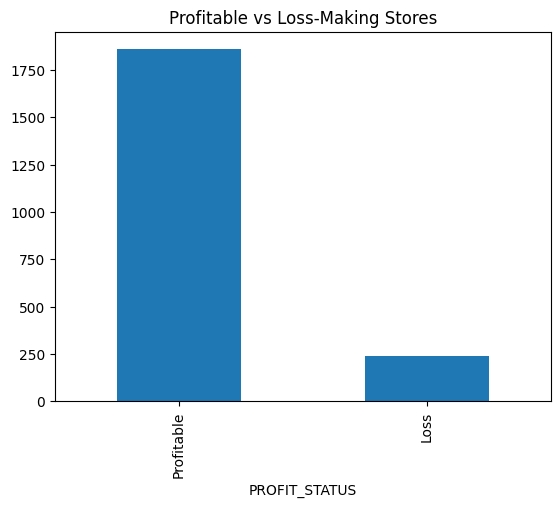

In [ ]:
df['PROFIT_STATUS'].value_counts().plot(kind='bar')

plt.title('Profitable vs Loss-Making Stores')

plt.show()

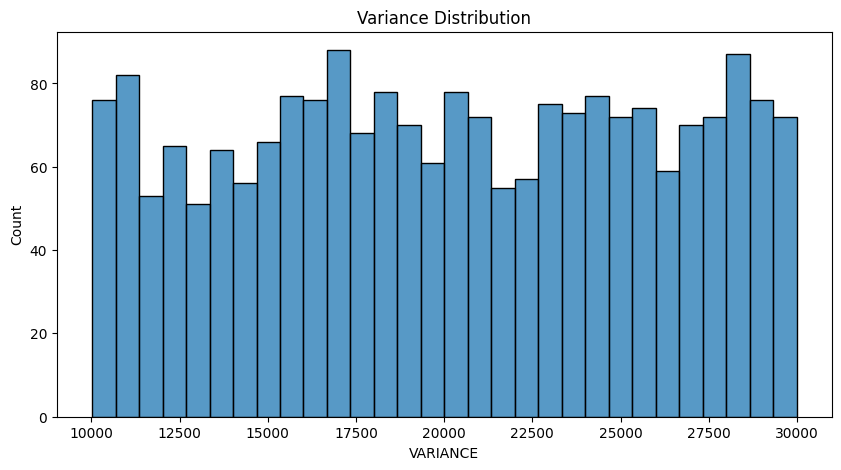

In [ ]:
plt.figure(figsize=(10,5))

sns.histplot(df['VARIANCE'], bins=30)

plt.title('Variance Distribution')

plt.show()

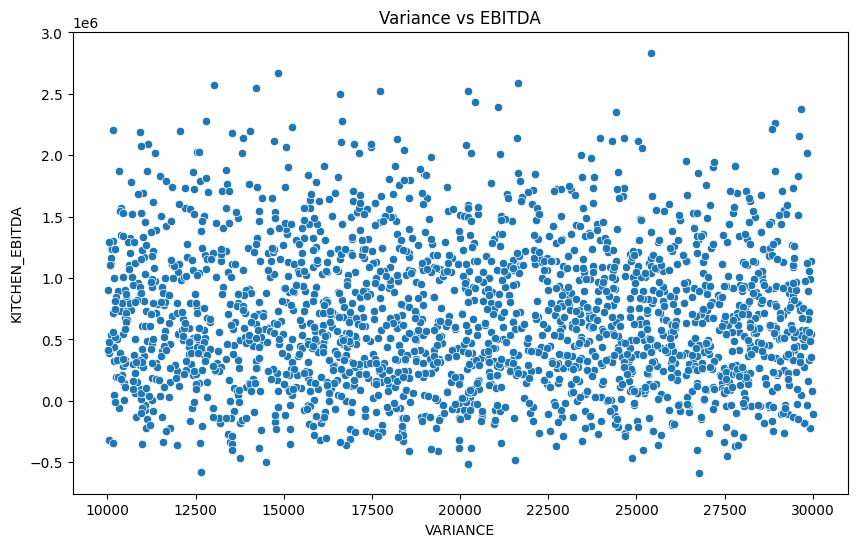

In [ ]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x=df['VARIANCE'],
    y=df['KITCHEN_EBITDA']
)

plt.title('Variance vs EBITDA')

plt.show()

If higher variance corresponds to lower EBITDA:
strong evidence that: food wastage hurts profitability

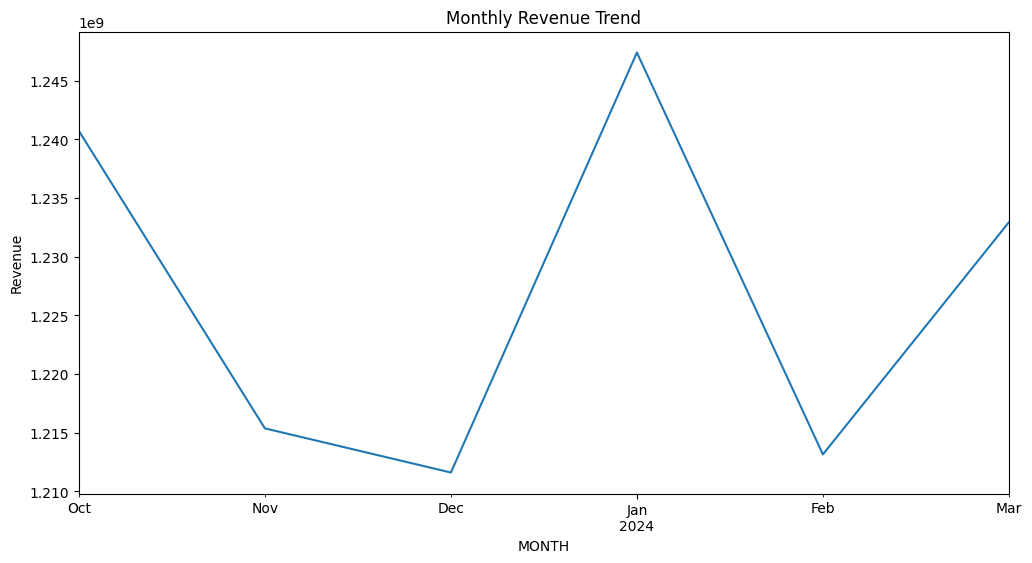

In [ ]:
plt.figure(figsize=(12,6))

monthly_revenue.plot()

plt.title('Monthly Revenue Trend')

plt.ylabel('Revenue')

plt.show()

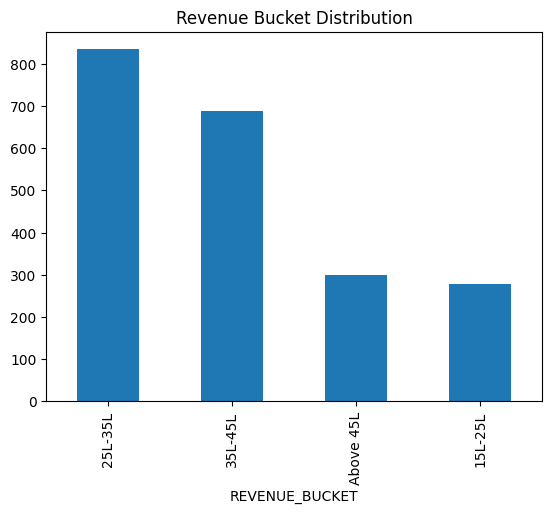

In [ ]:

df['REVENUE_BUCKET'].value_counts().plot(kind='bar')

plt.title('Revenue Bucket Distribution')

plt.show()

In [ ]:
df['VARIANCE'].describe()

count     2100.000000
mean     20176.588981
std       5783.204330
min      10018.480000
25%      15494.855000
50%      20195.190000
75%      25180.827500
max      29993.940000
Name: VARIANCE, dtype: float64

In [ ]:
df['VARIANCE'] = df['VARIANCE'] / 10000

In [ ]:
df['VARIANCE'].describe()

count    2100.000000
mean        2.017659
std         0.578320
min         1.001848
25%         1.549486
50%         2.019519
75%         2.518083
max         2.999394
Name: VARIANCE, dtype: float64